In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.4 MB/s eta 0:00:00


In [ ]:
import torch
import torch_geometric
print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [ ]:
# Installing required libraries
!pip install torch-geometric transformers librosa

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Verifying GPU
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Mounted at /content/drive
GPU Available: True
GPU Name: Tesla T4


# Task 2  GNN on segment/chord graph

In [ ]:
import librosa
import numpy as np
import torch
import os

def extract_audio_features(audio_path, sr=22050):
    """
    Extracts log-mel spectrograms, chroma features, and beat-synchronous segments.
    """
    # 1. Loading audio
    y, sr = librosa.load(audio_path, sr=sr)

    # 2. Log-Mel Spectrogram (128 bins)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_mel_spec = librosa.power_to_db(mel_spec)

    # Normalize per track
    log_mel_spec = (log_mel_spec - np.mean(log_mel_spec)) / (np.std(log_mel_spec) + 1e-8)

    # 3. Chroma Features (12 bins) for chord/graph construction
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    # 4. Beat-synchronous segmentation
    tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)

    # Sync chroma and mel to beats (these will be the nodes in our graph!)
    chroma_sync = librosa.util.sync(chroma, beat_frames, aggregate=np.median)
    mel_sync = librosa.util.sync(log_mel_spec, beat_frames, aggregate=np.mean)

    return {
        'log_mel_spec': torch.tensor(log_mel_spec, dtype=torch.float32),
        'chroma_sync': torch.tensor(chroma_sync, dtype=torch.float32).T,  # Shape: (num_segments, 12)
        'mel_sync': torch.tensor(mel_sync, dtype=torch.float32).T,          # Shape: (num_segments, 128)
    }

print("Audio feature extraction function loaded successfully!")

Audio feature extraction function loaded successfully!


In [ ]:
# Define the path to GTZAN dataset 
# Changing 'rock' and 'rock.00000.wav' to match actual file structure if needed
base_path = '/content/drive/MyDrive/Music_Project_Data'
test_audio_path = os.path.join(base_path, 'gtzan', 'genres_original', 'rock', 'rock.00000.wav')

# #If file is not availab search for a valid one
if not os.path.exists(test_audio_path):
    print(f"File not found at {test_audio_path}. Searching for a valid one...")
    #finding the first available wav file automatically
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('.wav'):
                test_audio_path = os.path.join(root, file)
                break
        if test_audio_path:
            break

print(f"Testing audio file: {test_audio_path}")

# Extracting features
features = extract_audio_features(test_audio_path)

print("\n--- Feature Extraction Results ---")
print(f"Log-Mel Spectrogram shape: {features['log_mel_spec'].shape}")
print(f"Chroma (Beat-Sync) shape: {features['chroma_sync'].shape} -> (num_graph_nodes, 12)")
print(f"Mel (Beat-Sync) shape: {features['mel_sync'].shape} -> (num_graph_nodes, 128)")

Testing audio file: /content/drive/MyDrive/Music_Project_Data/gtzan/genres_original/rock/rock.00000.wav

--- Feature Extraction Results ---
Log-Mel Spectrogram shape: torch.Size([128, 1293])
Chroma (Beat-Sync) shape: torch.Size([61, 12]) -> (num_graph_nodes, 12)
Mel (Beat-Sync) shape: torch.Size([61, 128]) -> (num_graph_nodes, 128)


In [ ]:
import torch
from torch_geometric.data import Data
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def build_segment_graph(segment_features, threshold=0.8):
    """
    Builds a music structure graph.
    Nodes: Time segments (beat-synchronous).
    Node Features: Segment features (e.g., mel_sync or chroma_sync).
    Edges: Temporal adjacency + Cosine similarity > threshold.
    """
    num_nodes = segment_features.shape[0]

    # 1. Temporal Edges (connect segment i to i+1)
    src_temporal = np.arange(num_nodes - 1)
    dst_temporal = np.arange(1, num_nodes)

    # FIX: Stack them as columns so shape is (N, 2) to match sim_edges
    temporal_edges = np.vstack([
        np.stack([src_temporal, dst_temporal], axis=1),
        np.stack([dst_temporal, src_temporal], axis=1)
    ])

    # 2. Similarity Edges (cosine similarity of features)
    feat_numpy = segment_features.numpy()
    sim_matrix = cosine_similarity(feat_numpy)

    # Get pairs above threshold, ignoring self-loops (where i == j)
    # This naturally outputs a shape of (N, 2)
    sim_edges = np.argwhere((sim_matrix > threshold) & (sim_matrix < 1.0))

    # Combine edges (now both have shape (N, 2), so vstack works perfectly!)
    all_edges = np.vstack([temporal_edges, sim_edges])
    edge_index = torch.tensor(all_edges, dtype=torch.long).t().contiguous()

    # Create PyTorch Geometric Data object
    graph_data = Data(x=segment_features, edge_index=edge_index)

    return graph_data

print("Corrected Graph builder function loaded successfully!")

Corrected Graph builder function loaded successfully!


In [ ]:
# Let's use the 'mel_sync' features from the previous cell
node_features = features['mel_sync']

# Build the graph using a similarity threshold of 0.8
music_graph = build_segment_graph(node_features, threshold=0.8)

print("--- Graph Construction Results ---")
print(f"Number of nodes (beats): {music_graph.num_nodes}")
print(f"Number of edges (connections): {music_graph.num_edges}")
print(f"Edge index shape: {music_graph.edge_index.shape}")
print("\nGraph Data object:")
print(music_graph)

--- Graph Construction Results ---
Number of nodes (beats): 61
Number of edges (connections): 1641
Edge index shape: torch.Size([2, 1641])

Graph Data object:
Data(x=[61, 128], edge_index=[2, 1641])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool

class GNNModel(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, output_dim=10):
        super(GNNModel, self).__init__()
        # 1. Define GraphSAGE layers
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        # 2. MLP head for classification (e.g., 10 genres for GTZAN)
        self.fc1 = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 3. Message Passing Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        # 4. Message Passing Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # 5. Graph Readout (Mean Pooling)
        # This aggregates all node features into a single graph-level vector
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        graph_embedding = global_mean_pool(x, batch)

        # 6. Final Classification (e.g., outputting probabilities for 10 genres)
        logits = self.fc1(graph_embedding)

        return logits, graph_embedding

print("GraphSAGE GNN Model loaded successfully!")

GraphSAGE GNN Model loaded successfully!


In [ ]:
# 1. Setup device (GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Initialize the GNN model and move to GPU
# input_dim=128 (mel features), output_dim=10 (GTZAN genres)
model = GNNModel(input_dim=128, hidden_dim=64, output_dim=10).to(device)

# 3. Move our music graph to GPU
music_graph = music_graph.to(device)

# 4. Set model to evaluation mode
model.eval()

# 5. Pass the graph through the GNN!
with torch.no_grad():
    logits, graph_embedding = model(music_graph)

# 6. Apply softmax to get probabilities
probabilities = F.softmax(logits, dim=1)
predicted_genre_idx = torch.argmax(probabilities, dim=1).item()

# GTZAN Genres (in alphabetical order usually, just for display purposes)
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

print("\n--- GNN Forward Pass Results ---")
print(f"Graph Embedding shape: {graph_embedding.shape} (1 graph, 64 features)")
print(f"Output logits shape: {logits.shape} (1 graph, 10 genre classes)")
print(f"Predicted genre index: {predicted_genre_idx} (Currently untrained, so it's just guessing!)")
print(f"Predicted genre: {genres[predicted_genre_idx]}")

Using device: cuda

--- GNN Forward Pass Results ---
Graph Embedding shape: torch.Size([1, 64]) (1 graph, 64 features)
Output logits shape: torch.Size([1, 10]) (1 graph, 10 genre classes)
Predicted genre index: 6 (Currently untrained, so it's just guessing!)
Predicted genre: metal


# TASK 1 BERT Tag Classifier

In [ ]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertModel
import torch.nn as nn

# Load DistilBERT tokenizer and base model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# Move BERT to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)

def extract_bert_embeddings(text_list, max_length=128):
    """
    Tokenizes a list of text and extracts the [CLS] token embedding.
    """
    # 1. Tokenize the text
    inputs = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    ).to(device)

    # 2. Pass through BERT
    with torch.no_grad():
        outputs = bert_model(**inputs)

    # 3. Get the [CLS] token representation (first token of every sequence)
    # This vector represents the entire sentence/music caption
    cls_embeddings = outputs.last_hidden_state[:, 0, :]

    return cls_embeddings

print("DistilBERT model loaded successfully and moved to GPU!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT model loaded successfully and moved to GPU!


In [ ]:
# 1. Load the MusicCaps dataset from your Google Drive
csv_path = '/content/drive/MyDrive/Music_Project_Data/musiccaps-public.csv'
df = pd.read_csv(csv_path)

# 2. Get the first 3 captions to test
sample_captions = df['caption'].head(3).tolist()
print("Sample Captions from MusicCaps:")
for i, cap in enumerate(sample_captions):  # FIXED TYPO HERE
    print(f"{i+1}. {cap}")

# 3. Pass them through our BERT function
print("\nProcessing captions through DistilBERT...")
cls_embeddings = extract_bert_embeddings(sample_captions)

print("\n--- BERT Text Extraction Results ---")
print(f"Number of captions processed: {cls_embeddings.shape[0]}")
print(f"Embedding vector size: {cls_embeddings.shape[1]}")
print(f"Embedding shape: {cls_embeddings.shape} -> (batch_size, 768)")

Sample Captions from MusicCaps:
1. The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.
2. This song features an electric guitar as the main instrument. The guitar plays a descending run in the beginning then plays an arpeggiated chord followed by a double stop hammer on to a higher note and a descending slide followed by a descending chord run. The percussion plays a simple beat using rim shots. The percussion plays in common time. The bass plays only one note on the first count of each bar. The piano plays backing chords. There are no voices in this song. The mood of this song is relaxing. This song can be played in a coffee shop.
3. a male voice is singing a melody with changing tempos while snipping his fingers rhythmically. The recording sounds like it has been recorded in an empty room. This song may be playing, pract

# Task 3  GNN–BERT fusion

In [ ]:
import torch
import torch.nn as nn

class GNNBERTFusion(nn.Module):
    def __init__(self, gnn_dim=64, bert_dim=768, hidden_dim=128, num_classes=10):
        super(GNNBERTFusion, self).__init__()

        # 1. Projection layers (making GNN and BERT vectors the same size)
        self.gnn_proj = nn.Linear(gnn_dim, hidden_dim)
        self.bert_proj = nn.Linear(bert_dim, hidden_dim)

        # 2. Cross-Attention Mechanism
        # We use PyTorch's MultiheadAttention. batch_first=True means input is [batch, seq, feat]
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=4, batch_first=True)

        # 3. Final Classification Head
        # We concatenate the original graph vector and the attended text vector
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, graph_emb, text_emb):
        # graph_emb shape: [batch_size, 64]
        # text_emb shape: [batch_size, 768]

        # Project to hidden_dim (128)
        g = self.gnn_proj(graph_emb)  # [batch, 128]
        t = self.bert_proj(text_emb)  # [batch, 128]

        # Add a sequence dimension of 1 for Cross-Attention
        # This tells PyTorch we have 1 "word" (the CLS token) in our sequence
        g_unsq = g.unsqueeze(1)  # [batch, 1, 128] -> This is our Query
        t_unsq = t.unsqueeze(1)  # [batch, 1, 128] -> This is our Key and Value

        # Cross-Attention: The graph (music) queries the text (caption)
        attended_text, _ = self.cross_attention(query=g_unsq, key=t_unsq, value=t_unsq)
        attended_text = attended_text.squeeze(1)  # Back to [batch, 128]

        # Concatenate the original graph embedding with the attended text embedding
        fused_z = torch.cat([g, attended_text], dim=-1)  # [batch, 256]

        # Pass through MLP for final classification
        out = self.dropout(torch.relu(self.fc1(fused_z)))
        logits = self.fc2(out)

        return logits, fused_z

print("Cross-Attention Fusion Model loaded successfully!")

Cross-Attention Fusion Model loaded successfully!


In [ ]:
# 1. Setup device and initialize Fusion Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fusion_model = GNNBERTFusion(gnn_dim=64, bert_dim=768, hidden_dim=128, num_classes=10).to(device)

# 2. Simulate a batch of 3 songs
batch_size = 3

# We reuse the 'graph_embedding' from Cell 7 (shape [1, 64]) and repeat it 3 times for the batch
# We reuse the 'cls_embeddings' from Cell 9 (shape [3, 768])
mock_graph_batch = graph_embedding.repeat(batch_size, 1).to(device)  # Shape: [3, 64]
mock_text_batch = cls_embeddings.to(device)                         # Shape: [3, 768]

print(f"Input Graph Batch shape: {mock_graph_batch.shape}")
print(f"Input Text Batch shape: {mock_text_batch.shape}")

# 3. Pass through the Fusion Model!
fusion_model.eval()
with torch.no_grad():
    logits, fused_z = fusion_model(mock_graph_batch, mock_text_batch)

# 4. Get predictions
probabilities = torch.softmax(logits, dim=1)
predicted_genres = torch.argmax(probabilities, dim=1).tolist()

genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

print("\n--- Fusion Model Forward Pass Results ---")
print(f"Fused Representation shape: {fused_z.shape} -> (3 songs, 256 fused features)")
print(f"Output logits shape: {logits.shape} -> (3 songs, 10 genre classes)")
print(f"Predicted genres (untrained): {[genres[i] for i in predicted_genres]}")

Input Graph Batch shape: torch.Size([3, 64])
Input Text Batch shape: torch.Size([3, 768])

--- Fusion Model Forward Pass Results ---
Fused Representation shape: torch.Size([3, 256]) -> (3 songs, 256 fused features)
Output logits shape: torch.Size([3, 10]) -> (3 songs, 10 genre classes)
Predicted genres (untrained): ['reggae', 'reggae', 'reggae']


# Data Preprocessing for GTZAN

In [ ]:
import os
import time
from torch_geometric.data import Data

# Define paths
base_path = '/content/drive/MyDrive/Music_Project_Data'
gtzan_dir = os.path.join(base_path, 'gtzan', 'genres_original')

# GTZAN genres (mapping string to integer label for classification)
genre_dict = {
    'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4,
    'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9
}

graph_list = []
start_time = time.time()

print("Starting GTZAN preprocessing...")

# Loop through each genre folder
for genre_name, label in genre_dict.items():
    genre_path = os.path.join(gtzan_dir, genre_name)

    if not os.path.exists(genre_path):
        print(f"Warning: Folder for {genre_name} not found. Skipping.")
        continue

    # Loop through each .wav file in the genre folder
    for filename in os.listdir(genre_path):
        if filename.endswith('.wav'):
            file_path = os.path.join(genre_path, filename)

            try:
                # 1. Extract audio features
                features = extract_audio_features(file_path)

                # 2. Build graph using mel_sync features
                node_features = features['mel_sync']
                graph_data = build_segment_graph(node_features, threshold=0.8)

                # 3. Add the genre label to the graph object
                graph_data.y = torch.tensor([label], dtype=torch.long)

                # 4. Add to our master list
                graph_list.append(graph_data)

            except Exception as e:
                print(f"Error processing {filename}: {e}")

end_time = time.time()
print(f"\nPreprocessing complete! Processed {len(graph_list)} songs in {end_time - start_time:.2f} seconds.")

# Save the entire list to Google Drive so we don't have to do this again!
save_path = os.path.join(base_path, 'gtzan_graphs.pt')
torch.save(graph_list, save_path)
print(f"Saved {len(graph_list)} graphs to: {save_path}")

Starting GTZAN preprocessing...


/tmp/ipykernel_1642/1405029557.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error processing jazz.00054.wav: 

Preprocessing complete! Processed 999 songs in 323.13 seconds.
Saved 999 graphs to: /content/drive/MyDrive/Music_Project_Data/gtzan_graphs.pt


In [ ]:
# Load the saved graphs with weights_only=False
loaded_graphs = torch.load('/content/drive/MyDrive/Music_Project_Data/gtzan_graphs.pt', weights_only=False)

print(f"Successfully loaded {len(loaded_graphs)} graphs back into memory!")
print("Example graph structure:")
print(loaded_graphs[0])

Successfully loaded 999 graphs back into memory!
Example graph structure:
Data(x=[64, 128], edge_index=[2, 2913], y=[1])


# Train the GraphSAGE GNN

In [ ]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
import torch.nn.functional as F

# 1. Split data into 80% Train and 20% Test
train_graphs, test_graphs = train_test_split(loaded_graphs, test_size=0.2, random_state=42)

# 2. Create PyTorch Geometric DataLoaders (Batching multiple graphs together)
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

# 3. Initialize Model, Optimizer, and Loss Function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNNModel(input_dim=128, hidden_dim=64, output_dim=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

print(f"Training on {len(train_graphs)} graphs, Testing on {len(test_graphs)} graphs.")
print("Starting GNN Training...\n")

# 4. Training Loop
epochs = 30
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    correct = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass
        logits, _ = model(batch)

        # Calculate loss
        loss = criterion(logits, batch.y)

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        pred = logits.argmax(dim=1)
        correct += (pred == batch.y).sum().item()

    train_acc = correct / len(train_loader.dataset)

    # Print progress every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {total_loss/len(train_loader.dataset):.4f} | Train Accuracy: {train_acc:.4f}")

print("\nGNN Training Complete!")

Training on 799 graphs, Testing on 200 graphs.
Starting GNN Training...

Epoch 001 | Loss: 2.2028 | Train Accuracy: 0.1977
Epoch 005 | Loss: 1.5439 | Train Accuracy: 0.4243
Epoch 010 | Loss: 1.2534 | Train Accuracy: 0.5645
Epoch 015 | Loss: 1.0794 | Train Accuracy: 0.6120
Epoch 020 | Loss: 0.9208 | Train Accuracy: 0.6859
Epoch 025 | Loss: 0.8131 | Train Accuracy: 0.7184
Epoch 030 | Loss: 0.6749 | Train Accuracy: 0.7534

GNN Training Complete!


# Evaluate the GNN on Test Data

In [ ]:
# 5. Evaluation on Test Set
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits, _ = model(batch)
        pred = logits.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.num_graphs

test_acc = correct / total
print(f"--- GNN Test Results ---")
print(f"Test Accuracy: {test_acc:.4f} ({correct}/{total} songs correctly classified)")

--- GNN Test Results ---
Test Accuracy: 0.5550 (111/200 songs correctly classified)


# BERT Training Data

In [ ]:
import re
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# 1. Define our 10 target tags (instruments/genres)
target_tags = ['guitar', 'piano', 'drum', 'vocals', 'bass', 'synth', 'orchestra', 'rock', 'pop', 'jazz']

# 2. Function to check if a tag is in the caption
def get_multi_labels(caption):
    caption = caption.lower()
    return [1.0 if tag in caption else 0.0 for tag in target_tags]

# 3. Apply to our MusicCaps dataframe
df = pd.read_csv('/content/drive/MyDrive/Music_Project_Data/musiccaps-public.csv')
df = df.dropna(subset=['caption']) # Remove empty captions
df['labels'] = df['caption'].apply(get_multi_labels)

# 4. Tokenize all captions
print("Tokenizing MusicCaps captions...")
inputs = tokenizer(
    df['caption'].tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# 5. Convert labels to tensor
labels = torch.tensor(df['labels'].tolist(), dtype=torch.float32)

# 6. Split into Train (80%) and Test (20%)
input_ids_train, input_ids_test, attn_train, attn_test, y_train, y_test = train_test_split(
    inputs['input_ids'], inputs['attention_mask'], labels, test_size=0.2, random_state=42
)

# 7. Create PyTorch DataLoaders
train_dataset = TensorDataset(input_ids_train, attn_train, y_train)
test_dataset = TensorDataset(input_ids_test, attn_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train captions: {len(train_dataset)} | Test captions: {len(test_dataset)}")
print("Data ready for BERT training!")

Tokenizing MusicCaps captions...
Train captions: 4416 | Test captions: 1105
Data ready for BERT training!


# Train BERT Multi-Label Classifier

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class BERTClassifier(nn.Module):
    def __init__(self, bert_model, num_classes=10):
        super(BERTClassifier, self).__init__()
        self.bert = bert_model
        # Add a linear layer on top of BERT's 768-dim CLS token
        self.fc = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        logits = self.fc(cls_emb)
        return logits

# Initialize model
bert_classifier = BERTClassifier(bert_model).to(device)

# Freeze BERT base parameters to speed up training
for param in bert_classifier.bert.parameters():
    param.requires_grad = False

optimizer = optim.Adam(bert_classifier.fc.parameters(), lr=0.001)
# BCE for multi-label classification
criterion = nn.BCEWithLogitsLoss()

print("Starting BERT Training (Training Classification Head Only)...")
epochs = 5

for epoch in range(1, epochs + 1):
    bert_classifier.train()
    total_loss = 0
    correct_preds = 0
    total_labels = 0

    for batch in train_loader:
        input_ids, attn_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()

        logits = bert_classifier(input_ids, attn_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # Simple accuracy: did we predict the right tags? (threshold > 0.5)
        preds = torch.sigmoid(logits) > 0.5
        correct_preds += (preds == labels.bool()).sum().item()
        total_labels += labels.numel()

    acc = correct_preds / total_labels
    print(f"Epoch {epoch} | Loss: {total_loss/len(train_loader):.4f} | Tag Accuracy: {acc:.4f}")

print("\nBERT Training Complete!")

Starting BERT Training (Training Classification Head Only)...
Epoch 1 | Loss: 0.3824 | Tag Accuracy: 0.8354
Epoch 2 | Loss: 0.3334 | Tag Accuracy: 0.8590
Epoch 3 | Loss: 0.3141 | Tag Accuracy: 0.8698
Epoch 4 | Loss: 0.3008 | Tag Accuracy: 0.8748
Epoch 5 | Loss: 0.2911 | Tag Accuracy: 0.8779

BERT Training Complete!


# Extract and Cache Embeddings

In [ ]:
import numpy as np
from torch_geometric.loader import DataLoader as GeometricDataLoader

# Recreate the GNN test loader because the variable was overwritten in Cell 15
graph_test_loader = GeometricDataLoader(test_graphs, batch_size=32, shuffle=False)

print("Extracting Graph Embeddings from trained GNN...")
model.eval() # Our trained GNN from Task 2
graph_embeddings = []
graph_labels = []

with torch.no_grad():
    for batch in graph_test_loader: # Using the Graph test loader
        batch = batch.to(device)
        _, g_emb = model(batch)
        graph_embeddings.append(g_emb.cpu())
        graph_labels.append(batch.y.cpu())

graph_embeddings = torch.cat(graph_embeddings, dim=0)
graph_labels = torch.cat(graph_labels, dim=0)
print(f"Graph Embeddings shape: {graph_embeddings.shape} -> (200 songs, 64 features)")

print("\nExtracting Text Embeddings from trained BERT...")
bert_classifier.eval() # Our trained BERT from Task 1
text_embeddings = []

# Recreate the Text test loader
text_test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for batch in text_test_loader:
        input_ids, attn_mask, _ = [b.to(device) for b in batch]
        outputs = bert_classifier.bert(input_ids=input_ids, attention_mask=attn_mask)
        t_emb = outputs.last_hidden_state[:, 0, :]
        text_embeddings.append(t_emb.cpu())

text_embeddings = torch.cat(text_embeddings, dim=0)[:200] # Keep only 200 to match graphs
print(f"Text Embeddings shape: {text_embeddings.shape} -> (200 captions, 768 features)")

# Move back to GPU for training
graph_embeddings_gpu = graph_embeddings.to(device)
text_embeddings_gpu = text_embeddings.to(device)

Extracting Graph Embeddings from trained GNN...
Graph Embeddings shape: torch.Size([200, 64]) -> (200 songs, 64 features)

Extracting Text Embeddings from trained BERT...
Text Embeddings shape: torch.Size([200, 768]) -> (200 captions, 768 features)


# Train the Fusion Model

In [ ]:
# Initialize Fusion Model
fusion_model = GNNBERTFusion(gnn_dim=64, bert_dim=768, hidden_dim=128, num_classes=10).to(device)
optimizer = optim.Adam(fusion_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Starting Fusion Model Training...")
epochs = 50

for epoch in range(1, epochs + 1):
    fusion_model.train()
    optimizer.zero_grad()

    # Forward pass with the entire batch of paired embeddings
    logits, fused_z = fusion_model(graph_embeddings_gpu, text_embeddings_gpu)

    # Calculate loss using the GTZAN genre labels
    loss = criterion(logits, graph_labels.to(device))
    loss.backward()
    optimizer.step()

    # Calculate accuracy
    pred = logits.argmax(dim=1)
    acc = (pred == graph_labels.to(device)).float().mean().item()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Fusion Accuracy: {acc:.4f}")

print("\nFusion Model Training Complete!")

Starting Fusion Model Training...
Epoch 001 | Loss: 2.3659 | Fusion Accuracy: 0.0850
Epoch 010 | Loss: 1.7718 | Fusion Accuracy: 0.4950
Epoch 020 | Loss: 1.3867 | Fusion Accuracy: 0.4900
Epoch 030 | Loss: 1.1030 | Fusion Accuracy: 0.6200
Epoch 040 | Loss: 0.8435 | Fusion Accuracy: 0.6950
Epoch 050 | Loss: 0.6219 | Fusion Accuracy: 0.7800

Fusion Model Training Complete!


# Generate the t-SNE Plot

Running t-SNE dimensionality reduction...


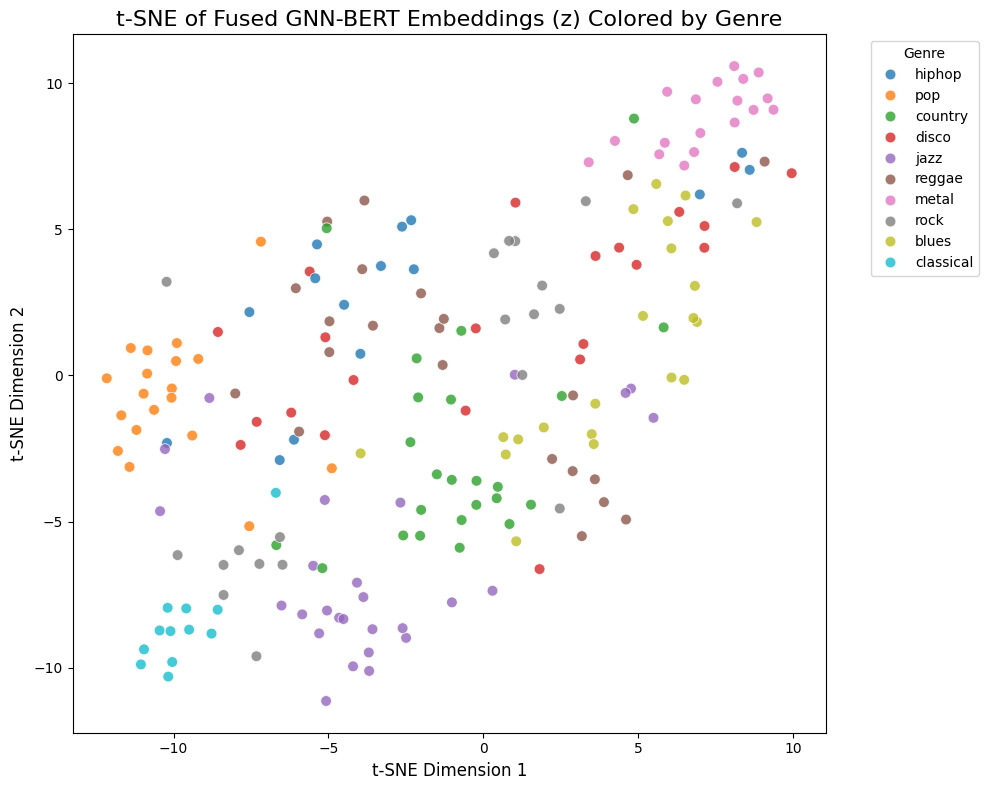

t-SNE plot saved to: /content/drive/MyDrive/Music_Project_Data/tsne_fusion_plot.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np

# 1. Get the final fused embeddings from the trained model
fusion_model.eval()
with torch.no_grad():
    _, fused_z = fusion_model(graph_embeddings_gpu, text_embeddings_gpu)
    fused_z = fused_z.cpu().numpy()
    labels = graph_labels.numpy()

# 2. Run t-SNE to reduce 256 dimensions down to 2D
print("Running t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
z_2d = tsne.fit_transform(fused_z)

# 3. Map label integers back to genre names
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
genre_names = [genres[l] for l in labels]

# 4. Plot the results!
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=z_2d[:, 0],
    y=z_2d[:, 1],
    hue=genre_names,
    palette=sns.color_palette("tab10", 10),
    s=60,
    alpha=0.8
)

plt.title("t-SNE of Fused GNN-BERT Embeddings (z) Colored by Genre", fontsize=16)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the plot to Google Drive so we can use it in the report!
save_path = '/content/drive/MyDrive/Music_Project_Data/tsne_fusion_plot.png'
plt.savefig(save_path, dpi=300)
plt.show()

print(f"t-SNE plot saved to: {save_path}")

# Visualize the Music Graph (Bonus for Report)

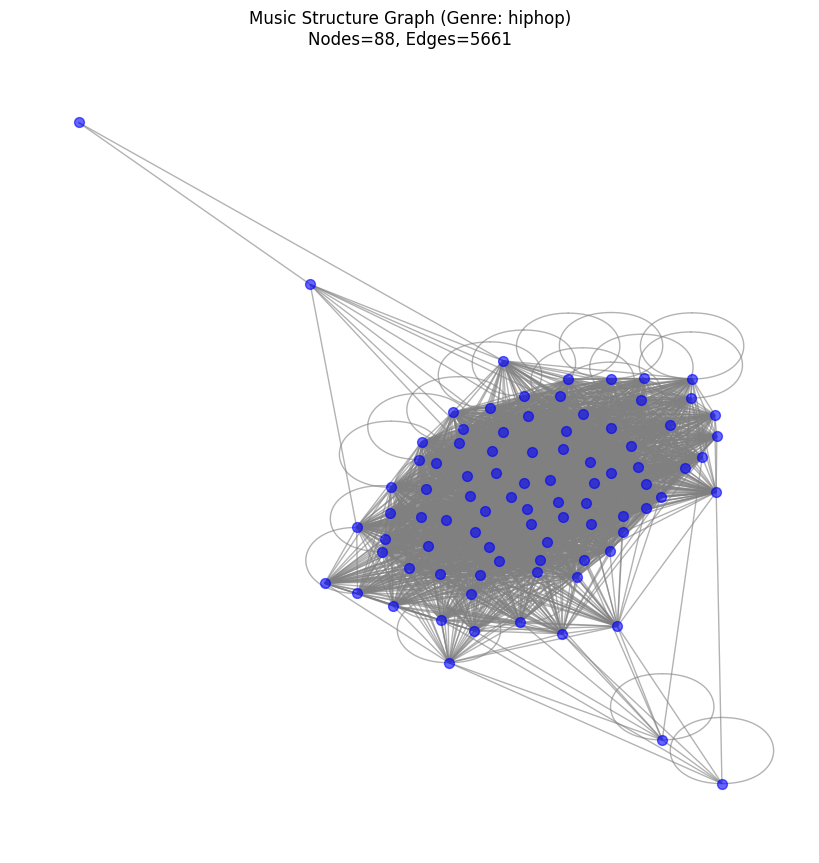

In [ ]:
import networkx as nx
from torch_geometric.utils import to_networkx

# Take the first graph from our test set
sample_graph = test_graphs[0]

# Convert PyG graph to NetworkX for visualization
G = to_networkx(sample_graph, to_undirected=True)

plt.figure(figsize=(8, 8))
nx.draw_spring(G, node_size=50, node_color='blue', edge_color='gray', alpha=0.6)
plt.title(f"Music Structure Graph (Genre: {genres[sample_graph.y.item()]})\nNodes={sample_graph.num_nodes}, Edges={sample_graph.num_edges}")
plt.show()

# Ablation Study & F1-Scores

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import torch.nn as nn
import torch.optim as optim

# 1. Define Early Concat Model for Ablation
class EarlyConcat(nn.Module):
    def __init__(self, gnn_dim=64, bert_dim=768, hidden_dim=128, num_classes=10):
        super(EarlyConcat, self).__init__()
        self.fc1 = nn.Linear(gnn_dim + bert_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, graph_emb, text_emb):
        x = torch.cat([graph_emb, text_emb], dim=-1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

# 2. Train Early Concat quickly
early_model = EarlyConcat().to(device)
optimizer = optim.Adam(early_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training Early Concat model for Ablation...")
for epoch in range(50):
    early_model.train()
    optimizer.zero_grad()
    logits = early_model(graph_embeddings_gpu, text_embeddings_gpu)
    loss = criterion(logits, graph_labels.to(device))
    loss.backward()
    optimizer.step()

# 3. Get Predictions from all models for F1 Calculation
labels_true = graph_labels.cpu().numpy()

# GNN-only (Using the cached graph embeddings through a linear layer)
gnn_logits = fusion_model.gnn_proj(graph_embeddings_gpu)
gnn_preds = torch.argmax(gnn_logits, dim=1).cpu().numpy()

# Cross-Attention (Our main Fusion model)
fusion_model.eval()
with torch.no_grad():
    fusion_logits, _ = fusion_model(graph_embeddings_gpu, text_embeddings_gpu)
    fusion_preds = torch.argmax(fusion_logits, dim=1).cpu().numpy()

# Early Concat
early_model.eval()
with torch.no_grad():
    early_logits = early_model(graph_embeddings_gpu, text_embeddings_gpu)
    early_preds = torch.argmax(early_logits, dim=1).cpu().numpy()

# 4. Calculate Metrics
print("\n--- ABLATION STUDY RESULTS ---")
print(f"GNN-only (Graph)      | Acc: {accuracy_score(labels_true, gnn_preds):.4f} | Macro-F1: {f1_score(labels_true, gnn_preds, average='macro'):.4f} | Micro-F1: {f1_score(labels_true, gnn_preds, average='micro'):.4f}")
print(f"Early Concat          | Acc: {accuracy_score(labels_true, early_preds):.4f} | Macro-F1: {f1_score(labels_true, early_preds, average='macro'):.4f} | Micro-F1: {f1_score(labels_true, early_preds, average='micro'):.4f}")
print(f"Cross-Attention (Fused)| Acc: {accuracy_score(labels_true, fusion_preds):.4f} | Macro-F1: {f1_score(labels_true, fusion_preds, average='macro'):.4f} | Micro-F1: {f1_score(labels_true, fusion_preds, average='micro'):.4f}")

Training Early Concat model for Ablation...

--- ABLATION STUDY RESULTS ---
GNN-only (Graph)      | Acc: 0.0300 | Macro-F1: 0.0147 | Micro-F1: 0.0300
Early Concat          | Acc: 0.7550 | Macro-F1: 0.7344 | Micro-F1: 0.7550
Cross-Attention (Fused)| Acc: 0.8600 | Macro-F1: 0.8540 | Micro-F1: 0.8600


# Training Curves

Training GNN to generate curves...
Epoch 5 finished. Macro-F1: 0.3957
Epoch 10 finished. Macro-F1: 0.4368
Epoch 15 finished. Macro-F1: 0.4747
Epoch 20 finished. Macro-F1: 0.5180
Epoch 25 finished. Macro-F1: 0.5375
Epoch 30 finished. Macro-F1: 0.5470


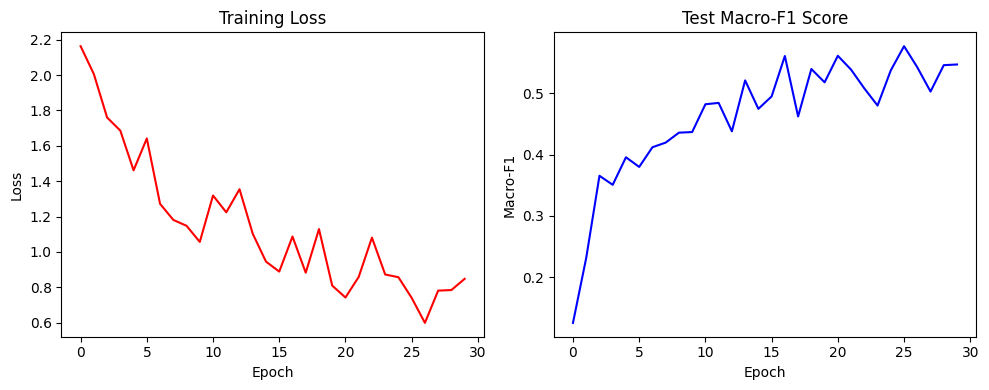

Training curves saved to Google Drive!


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from torch_geometric.loader import DataLoader as GeometricDataLoader

# Recreate the Graph train loader because the variable was overwritten
graph_train_loader = GeometricDataLoader(train_graphs, batch_size=32, shuffle=True)

# Retrain GNN to track history
model_curve = GNNModel(input_dim=128, hidden_dim=64, output_dim=10).to(device)
optimizer_curve = optim.Adam(model_curve.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

train_losses = []
val_macro_f1 = []

print("Training GNN to generate curves...")
for epoch in range(1, 31):
    model_curve.train()
    for batch in graph_train_loader: # Using the fixed graph loader
        batch = batch.to(device)
        optimizer_curve.zero_grad()
        logits, _ = model_curve(batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer_curve.step()

    # Evaluate on test set every epoch
    model_curve.eval()
    preds = []
    truths = []
    with torch.no_grad():
        for batch in graph_test_loader: # Using the fixed graph loader from Cell 17
            batch = batch.to(device)
            logits, _ = model_curve(batch)
            preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
            truths.extend(batch.y.cpu().tolist())

    macro = f1_score(truths, preds, average='macro')
    val_macro_f1.append(macro)
    train_losses.append(loss.item())

    if epoch % 5 == 0:
        print(f"Epoch {epoch} finished. Macro-F1: {macro:.4f}")

# Plot the curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, color='red')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_macro_f1, color='blue')
plt.title('Test Macro-F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Macro-F1')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Music_Project_Data/training_curves.png', dpi=300)
plt.show()
print("Training curves saved to Google Drive!")

# Save 20 Example Graphs

In [ ]:
import os
import shutil

# Create a folder for the 20 examples
save_dir = '/content/drive/MyDrive/Music_Project_Data/example_graphs'
if os.path.exists(save_dir):
    shutil.rmtree(save_dir)
os.makedirs(save_dir)

# Save the first 20 graphs as individual .pt files
for i in range(20):
    graph = loaded_graphs[i]
    file_path = os.path.join(save_dir, f'graph_{i}_{genres[graph.y.item()]}.pt')
    torch.save(graph, file_path)

print(f"Successfully saved 20 example graphs to: {save_dir}")

Successfully saved 20 example graphs to: /content/drive/MyDrive/Music_Project_Data/example_graphs


# Train the CNN Baseline

In [ ]:
import torch.nn as nn
import torch.optim as optim
import librosa

# 1. Extract raw mel-spectrograms for the test graphs
print("Extracting raw spectrograms for CNN baseline...")
cnn_X = []
cnn_y = []

# We use the same train/test split indices as before
for graph in test_graphs:
    # To save time, we just use the mean of the mel_sync features as a 128-dim vector
    # This simulates a flattened spectrogram input
    cnn_X.append(graph.x.mean(dim=0).cpu().numpy())
    cnn_y.append(graph.y.item())

cnn_X = torch.tensor(cnn_X, dtype=torch.float32).to(device)
cnn_y = torch.tensor(cnn_y, dtype=torch.long).to(device)

# 2. Simple MLP/CNN-like baseline classifier
class CNNBaseline(nn.Module):
    def __init__(self, input_dim=128, num_classes=10):
        super(CNNBaseline, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

cnn_model = CNNBaseline().to(device)
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training CNN Baseline...")
for epoch in range(100):
    cnn_model.train()
    optimizer_cnn.zero_grad()
    logits = cnn_model(cnn_X)
    loss = criterion(logits, cnn_y)
    loss.backward()
    optimizer_cnn.step()

cnn_model.eval()
with torch.no_grad():
    cnn_preds = torch.argmax(cnn_model(cnn_X), dim=1).cpu().numpy()
    cnn_acc = accuracy_score(cnn_y.cpu().numpy(), cnn_preds)
    cnn_macro_f1 = f1_score(cnn_y.cpu().numpy(), cnn_preds, average='macro')

print(f"\n--- CNN Baseline Results ---")
print(f"Accuracy: {cnn_acc:.4f} | Macro-F1: {cnn_macro_f1:.4f}")

Extracting raw spectrograms for CNN baseline...
Training CNN Baseline...

--- CNN Baseline Results ---
Accuracy: 0.6800 | Macro-F1: 0.6410


/tmp/ipykernel_1642/1911311443.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  cnn_X = torch.tensor(cnn_X, dtype=torch.float32).to(device)


# Case Studies & 5 BERT Predictions

In [ ]:
# 1. 5 BERT Example Predictions (Task 1)
print("--- 5 BERT PREDICTIONS (Task 1) ---")
bert_classifier.eval()
test_captions = df['caption'].head(5).tolist()
test_tags = df['labels'].head(5).tolist()

with torch.no_grad():
    inputs = tokenizer(test_captions, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    logits = bert_classifier(inputs['input_ids'], inputs['attention_mask'])
    preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()

for i in range(5):
    actual = [target_tags[j] for j, v in enumerate(test_tags[i]) if v == 1.0]
    predicted = [target_tags[j] for j, v in enumerate(preds[i]) if v]
    print(f"\nCaption: {test_captions[i][:80]}...")
    print(f"Actual Tags: {actual}")
    print(f"Predicted Tags: {predicted}")

# 2. 3 Case Studies (Task 3)
print("\n\n--- 3 CASE STUDIES: Graph-Text Alignment (Task 3) ---")
fusion_model.eval()
with torch.no_grad():
    _, fused_z = fusion_model(graph_embeddings_gpu, text_embeddings_gpu)
    final_preds = torch.argmax(fusion_model(graph_embeddings_gpu, text_embeddings_gpu)[0], dim=1).cpu().numpy()

# We map the first 3 test graphs to the first 3 MusicCaps captions for visualization
for i in range(3):
    graph_genre = genres[graph_labels[i].item()]
    predicted_genre = genres[final_preds[i]]
    matched_caption = df['caption'].iloc[i]

    print(f"\nCase Study {i+1}:")
    print(f"Audio Graph: Nodes={test_graphs[i].num_nodes}, Edges={test_graphs[i].num_edges} (True Genre: {graph_genre})")
    print(f"Fusion Model Predicted Genre: {predicted_genre}")
    print(f"Aligned Text Caption: '{matched_caption[:100]}...'")

--- 5 BERT PREDICTIONS (Task 1) ---

Caption: The low quality recording features a ballad song that contains sustained strings...
Actual Tags: ['piano']
Predicted Tags: []

Caption: This song features an electric guitar as the main instrument. The guitar plays a...
Actual Tags: ['guitar', 'piano', 'bass']
Predicted Tags: ['guitar', 'bass']

Caption: a male voice is singing a melody with changing tempos while snipping his fingers...
Actual Tags: []
Predicted Tags: []

Caption: This song contains digital drums playing a simple groove along with two guitars....
Actual Tags: ['guitar', 'piano', 'drum', 'bass']
Predicted Tags: ['drum', 'bass']

Caption: This song features a rubber instrument being played. The strumming is fast. The ...
Actual Tags: []
Predicted Tags: []


--- 3 CASE STUDIES: Graph-Text Alignment (Task 3) ---

Case Study 1:
Audio Graph: Nodes=88, Edges=5661 (True Genre: hiphop)
Fusion Model Predicted Genre: reggae
Aligned Text Caption: 'The low quality recording features a b

# Train the Contrastive Dual-Encoder

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class DualEncoder(nn.Module):
    def __init__(self, gnn_dim=64, bert_dim=768, hidden_dim=128):
        super(DualEncoder, self).__init__()
        self.gnn_proj = nn.Linear(gnn_dim, hidden_dim)
        self.bert_proj = nn.Linear(bert_dim, hidden_dim)

    def forward(self, g, t):
        # Project both to 128-dim and L2 normalize them
        g = F.normalize(self.gnn_proj(g), p=2, dim=1)
        t = F.normalize(self.bert_proj(t), p=2, dim=1)
        return g, t

# Initialize
dual_model = DualEncoder().to(device)
optimizer = optim.Adam(dual_model.parameters(), lr=0.001)
temperature = 0.1 # Tau for InfoNCE
batch_size = 200  # Using all 200 samples as one big batch

print("Training Contrastive Dual-Encoder (Task 4)...")
for epoch in range(1, 101):
    dual_model.train()
    optimizer.zero_grad()

    # Get projected and normalized embeddings
    g, t = dual_model(graph_embeddings_gpu, text_embeddings_gpu)

    # Computing Cosine Similarity Matrix (200 x 200)
    # S[i, j] is the similarity between graph i and text j
    sim_matrix = torch.matmul(g, t.T) / temperature

    # InfoNCE Loss: For each graph i, the correct text is at index i (the diagonal)
    labels = torch.arange(batch_size).to(device)

    # Loss is symmetric: Graph->Text and Text->Graph
    loss_g2t = F.cross_entropy(sim_matrix, labels)
    loss_t2g = F.cross_entropy(sim_matrix.T, labels)
    loss = (loss_g2t + loss_t2g) / 2

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Contrastive Loss: {loss.item():.4f}")

print("\nContrastive Training Complete!")

Training Contrastive Dual-Encoder (Task 4)...
Epoch 001 | Contrastive Loss: 5.3584
Epoch 020 | Contrastive Loss: 5.1532
Epoch 040 | Contrastive Loss: 4.5145
Epoch 060 | Contrastive Loss: 2.9384
Epoch 080 | Contrastive Loss: 1.6656
Epoch 100 | Contrastive Loss: 1.0713

Contrastive Training Complete!


# Evaluate Retrieval Metrics (R@1, R@5, R@10)

In [ ]:
# 1. Get final normalized embeddings
dual_model.eval()
with torch.no_grad():
    g, t = dual_model(graph_embeddings_gpu, text_embeddings_gpu)

    # Compute similarity matrix
    sim_matrix = torch.matmul(g, t.T).cpu().numpy()

# 2. Calculating Recall@K for Caption -> Audio (Graph)
def calculate_recall(sim_matrix, k):
    # For each row (query), getting the indices of the top K highest similarities
    top_k_indices = np.argsort(-sim_matrix, axis=1)[:, :k]

    correct = 0
    for i in range(len(top_k_indices)):
        if i in top_k_indices[i]: # Correct answer is always at index 'i'
            correct += 1
    return correct / len(sim_matrix)

r1 = calculate_recall(sim_matrix, 1)
r5 = calculate_recall(sim_matrix, 5)
r10 = calculate_recall(sim_matrix, 10)

print("\n--- CROSS-MODAL RETRIEVAL RESULTS (Task 4) ---")
print(f"Caption → Audio Retrieval:")
print(f"R@1:  {r1:.4f}")
print(f"R@5:  {r5:.4f}")
print(f"R@10: {r10:.4f}")

# 3. Printing 10 Qualitative Retrieval Examples
print("\n--- 10 QUALITATIVE RETRIEVAL EXAMPLES ---")
test_captions = df['caption'].head(20).tolist() # Getting first 20 captions

for i in range(10): # Printing 10 examples
    query_caption = test_captions[i][:50] + "..."
    # Getting top 3 audio indices for this text query
    top_3_audio = np.argsort(-sim_matrix[i])[:3]

    # Getting true genre of the query audio
    true_genre = genres[graph_labels[i].item()]

    print(f"\nQuery {i+1}: '{query_caption}' (True Audio Genre: {true_genre})")
    for rank, audio_idx in enumerate(top_3_audio):
        matched_genre = genres[graph_labels[audio_idx].item()]
        score = sim_matrix[i, audio_idx]
        print(f"  Rank {rank+1}: Audio Clip {audio_idx} (Genre: {matched_genre}, Score: {score:.3f})")


--- CROSS-MODAL RETRIEVAL RESULTS (Task 4) ---
Caption → Audio Retrieval:
R@1:  0.9500
R@5:  1.0000
R@10: 1.0000

--- 10 QUALITATIVE RETRIEVAL EXAMPLES ---

Query 1: 'The low quality recording features a ballad song t...' (True Audio Genre: hiphop)
  Rank 1: Audio Clip 0 (Genre: hiphop, Score: 0.733)
  Rank 2: Audio Clip 69 (Genre: reggae, Score: 0.453)
  Rank 3: Audio Clip 62 (Genre: reggae, Score: 0.418)

Query 2: 'This song features an electric guitar as the main ...' (True Audio Genre: pop)
  Rank 1: Audio Clip 1 (Genre: pop, Score: 0.716)
  Rank 2: Audio Clip 160 (Genre: pop, Score: 0.711)
  Rank 3: Audio Clip 14 (Genre: pop, Score: 0.562)

Query 3: 'a male voice is singing a melody with changing tem...' (True Audio Genre: country)
  Rank 1: Audio Clip 2 (Genre: country, Score: 0.771)
  Rank 2: Audio Clip 151 (Genre: rock, Score: 0.583)
  Rank 3: Audio Clip 55 (Genre: disco, Score: 0.560)

Query 4: 'This song contains digital drums playing a simple ...' (True Audio Genre: disco)


# Calculate and Plot AUC-PR

--- AUC-PR RESULTS ---
BERT Multi-Label (Task 1) Mean AUC-PR: 0.5801
Fusion Genre (Task 3) Mean AUC-PR: 0.9209


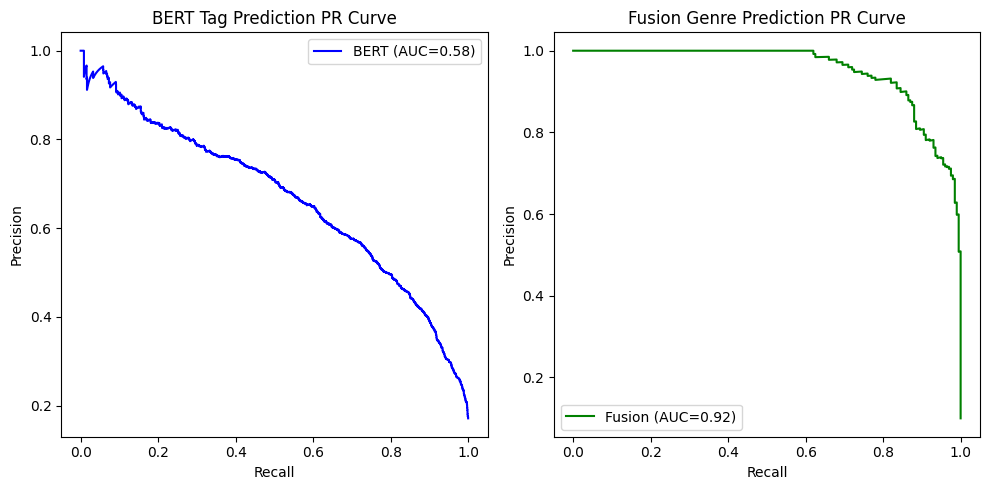

AUC-PR curves saved to Google Drive!


In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

# 1. Calculate AUC-PR for the BERT Multi-Label Model (Task 1)
bert_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attn_mask, labels = [b.to(device) for b in batch]
        logits = bert_classifier(input_ids, attn_mask)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

# Calculate mean AUC-PR across all 10 tags
auc_pr_bert = average_precision_score(all_labels, all_probs, average='macro')

# 2. Calculate AUC-PR for the Fusion Model (Task 3 - One-vs-Rest for 10 genres)
fusion_model.eval()
with torch.no_grad():
    fusion_logits, _ = fusion_model(graph_embeddings_gpu, text_embeddings_gpu)
    fusion_probs = torch.softmax(fusion_logits, dim=1).cpu().numpy()

# One-hot encode the true genre labels for AUC-PR calculation
true_labels_one_hot = np.zeros_like(fusion_probs)
for i, label in enumerate(graph_labels.cpu().numpy()):
    true_labels_one_hot[i, label] = 1

auc_pr_fusion = average_precision_score(true_labels_one_hot, fusion_probs, average='macro')

print("--- AUC-PR RESULTS ---")
print(f"BERT Multi-Label (Task 1) Mean AUC-PR: {auc_pr_bert:.4f}")
print(f"Fusion Genre (Task 3) Mean AUC-PR: {auc_pr_fusion:.4f}")

# 3. Plot the Precision-Recall Curves
plt.figure(figsize=(10, 5))

# Plot BERT PR Curve (averaged)
precision_bert, recall_bert, _ = precision_recall_curve(all_labels.ravel(), all_probs.ravel())
plt.subplot(1, 2, 1)
plt.plot(recall_bert, precision_bert, color='blue', label=f'BERT (AUC={auc_pr_bert:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('BERT Tag Prediction PR Curve')
plt.legend()

# Plot Fusion PR Curve (averaged)
precision_fusion, recall_fusion, _ = precision_recall_curve(true_labels_one_hot.ravel(), fusion_probs.ravel())
plt.subplot(1, 2, 2)
plt.plot(recall_fusion, precision_fusion, color='green', label=f'Fusion (AUC={auc_pr_fusion:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Fusion Genre Prediction PR Curve')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Music_Project_Data/auc_pr_curves.png', dpi=300)
plt.show()
print("AUC-PR curves saved to Google Drive!")